# singl varabel 

---
####  the main parameter 

In [108]:
import numpy as np
that0 = 0 # inintial the that0 
that1 = 0 #(that0,that1)the pramter f(x)=x*that1+that0
learingrate = 0.001
x= np.array([1,2,3,4])
y= np.array([3,5,7,9])
m = len(x)

---
####  main the fanc

In [114]:

def predict(x, theta1, theta0):
    """This function predicts y given x, theta1, and theta0."""
    return x * theta1 + theta0

def error_vector(y, y_predict):
    """Error vector = y - y_predict."""
    return y - y_predict

def compute_mse_cost(y, y_predict):
    """Computes Mean Squared Error cost."""
    error = y - y_predict
    m = len(y)
    mse_cost = (1 / (2 * m)) * np.dot(error, error)
    return mse_cost

def compute_gradients(X, y, y_predict):
    """Computes gradients for theta0 and theta1."""
    error =  y_predict - y
    m = len(y)
    gradient_theta_0 = (1 / m) * np.sum(error)
    gradient_theta_1 = (1 / m) * np.dot(x.T,error)
    return gradient_theta_0, gradient_theta_1

def update_parameters(theta_0, theta_1, gradient_theta_0, gradient_theta_1, learning_rate):
    """Updates theta0 and theta1 using the computed gradients."""
    new_theta_0 = theta_0 - learning_rate * gradient_theta_0
    new_theta_1 = theta_1 - learning_rate * gradient_theta_1
    return new_theta_0, new_theta_1


In [71]:
def gd(X, y, maxi=100, alpha=0.01):
    """Performs gradient descent to learn theta0 and theta1."""
    theta_0 = 0
    theta_1 = 0
    learning_rate = alpha
    arr_theta_0=[]
    arr_theta_1 =[]
    arr_losses = []
    for i in range(maxi):
        y_predict = predict(X, theta_1, theta_0)
        gradient_theta_0, gradient_theta_1 = compute_gradients(X, y, y_predict)
        theta_0, theta_1 = update_parameters(theta_0, theta_1, gradient_theta_0, gradient_theta_1, learning_rate)
        arr_theta_1.append(theta_1)
        arr_theta_0.append(theta_0)
        arr_losses.append(compute_mse_cost(y, y_predict))
        if i % 100 == 0:  
            print(f"Iteration {i}: Cost = {compute_mse_cost(y, y_predict)}")
    
    return arr_theta_0, arr_theta_1 ,arr_losses


theta0, theta1 ,arr_losses = gd(x, y, maxi=100, alpha=0.01)
print(f"Learned parameters: theta0 = {theta0[-1]}, theta1 = {theta1[-1]}")


Iteration 0: Cost = 20.5
Learned parameters: theta0 = 0.7531559602102061, theta1 = 2.08357483109694


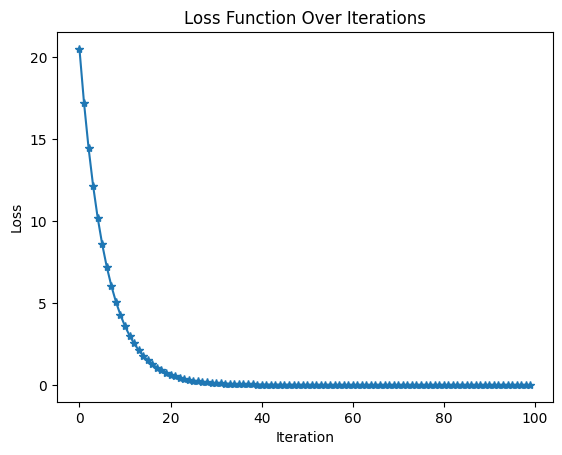

In [39]:
import matplotlib.pyplot as plt
plt.plot(arr_losses, linestyle='-', marker='*')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Loss Function Over Iterations')
plt.show()

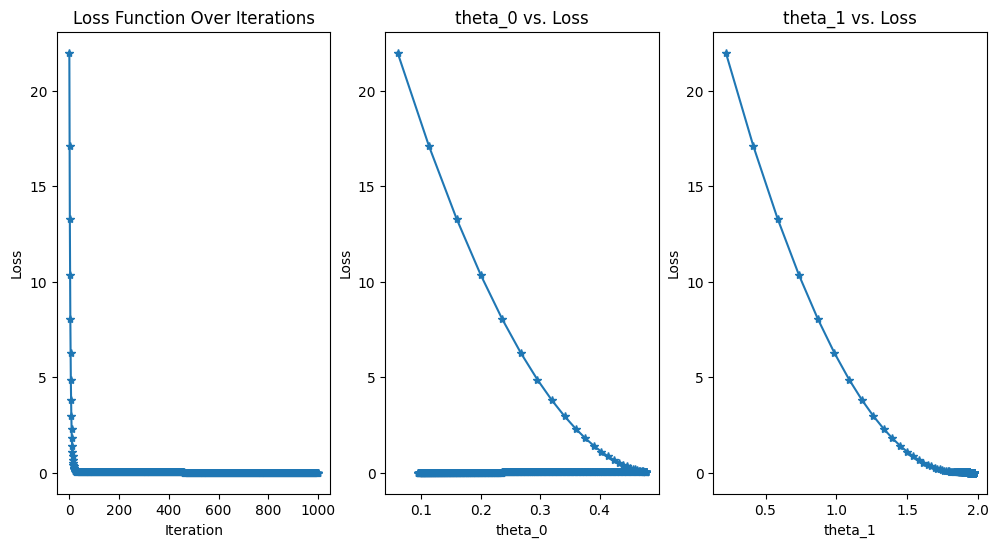

In [121]:
def plot_learning_curves (losses,theta_0_values,theta_1_values):
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 3, 1)
    plt.plot(losses, linestyle='-', marker='*')
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.title('Loss Function Over Iterations')
    plt.subplot(1, 3, 2)
    plt.plot(theta_0_values, losses, linestyle='-', marker='*')
    plt.xlabel('theta_0')
    plt.ylabel('Loss')
    plt.title('theta_0 vs. Loss')
    plt.subplot(1, 3, 3)
    plt.plot(theta_1_values, losses, linestyle='-', marker='*')
    plt.xlabel('theta_1')
    plt.ylabel('Loss')
    plt.title('theta_1 vs. Loss')
    plt.show()
plot_learning_curves (arr_losses,theta0, theta1)

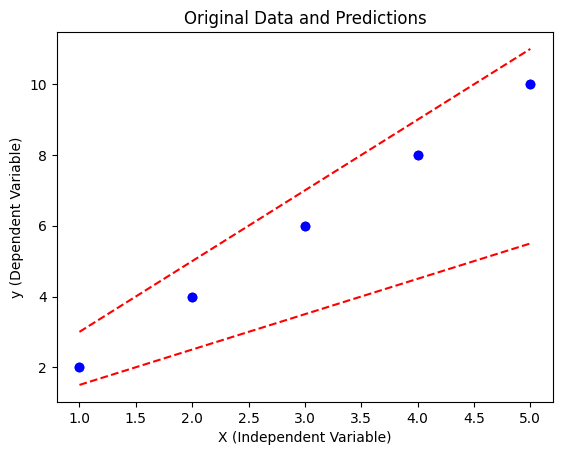

In [123]:
# use for compare betwen y and y predict one model 
def y_vs_ypredict(X,y,theta0,theta1,state=1):
    y_predict = predict(x, theta1, theta0)
    plt.scatter(X, y, color='blue', marker='o', label='Original data')
    plt.plot(X, y_predict, color='red', linestyle='--',label='Predicted ')
    plt.xlabel('X (Independent Variable)')
    plt.ylabel('y (Dependent Variable)')
    plt.title('Original Data and Predictions')
    if state==1:
        plt.legend()
        plt.show()
# use for compare betwem model  
def model_vs_model (X,y,theta0,theta1):
    for i in range(len(theta0)):
        y_vs_ypredict(X,y,theta0[i],theta1[i],state=2)
    plt.show()

theta01=[.5,1]
theta11=[1,2]
model_vs_model(x,y,theta01,theta11)


# Stochastic

In [112]:
def compute_gradients(X, y, y_predict):
    """Computes gradients for theta0 and theta1."""
    error = y_predict - y
    gradient_theta_0 = error
    gradient_theta_1 = X * error
    return gradient_theta_0, gradient_theta_1

Iteration 0: Cost = 22.0
Learned parameters: theta0 = 0.47748642478007336, theta1 = 1.85475191486763


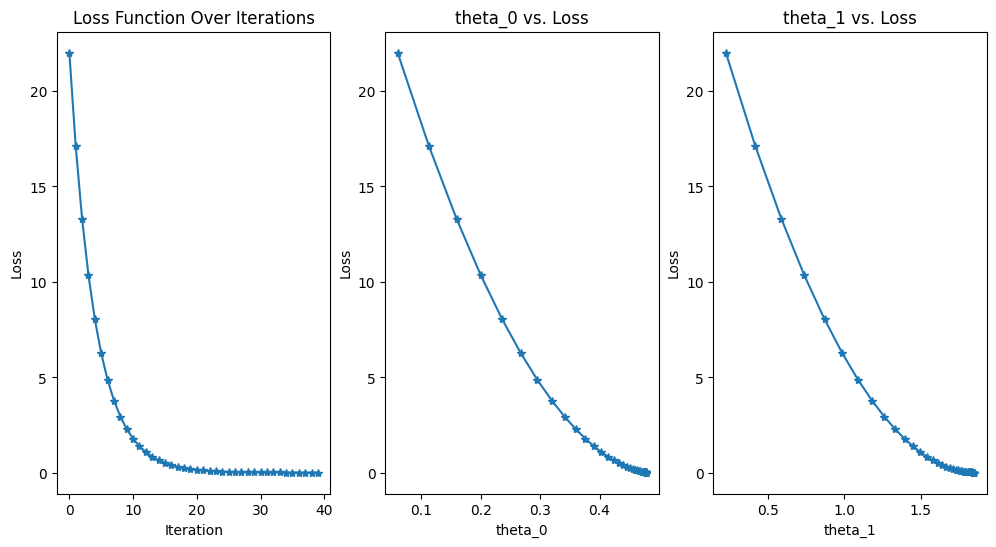

In [127]:
def Stochastic(X, y, maxi=100, alpha=0.01):
    """Performs gradient descent to learn theta0 and theta1."""
    theta_0 = 0
    theta_1 = 0
    learning_rate = alpha
    arr_theta_0 = []
    arr_theta_1 = []
    arr_losses = []
    for i in range(maxi):
        for ii in range(len(y)):
            y_predict = predict(X[ii], theta_1, theta_0)
            gradient_theta_0, gradient_theta_1 = compute_gradients(X[ii], y[ii], y_predict)
            theta_0, theta_1 = update_parameters(theta_0, theta_1, gradient_theta_0, gradient_theta_1, learning_rate)
        arr_theta_1.append(theta_1)
        arr_theta_0.append(theta_0)
        arr_losses.append(compute_mse_cost(y, predict(X, theta_1, theta_0)))
        if i % 100 == 0:
            print(f"Iteration {i}: Cost = {compute_mse_cost(y, predict(X, theta_1, theta_0))}")
    
    return arr_theta_0, arr_theta_1, arr_losses


theta0, theta1 ,arr_losses = gd(x, y, maxi=40, alpha=0.01)
print(f"Learned parameters: theta0 = {theta0[-1]}, theta1 = {theta1[-1]}")
plot_learning_curves (arr_losses,theta0,theta1)


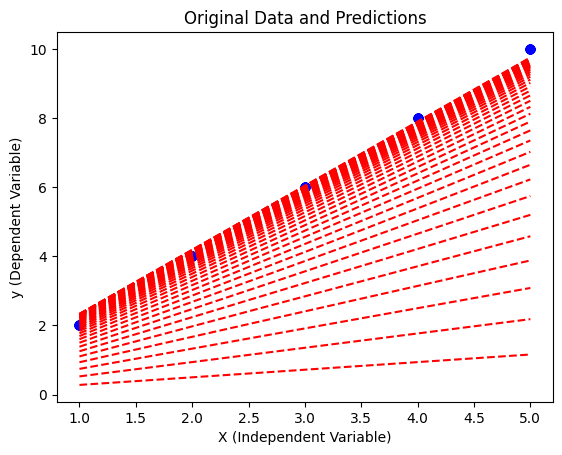

In [128]:
model_vs_model(x,y,theta0,theta1)

# mini bashe

# malty

---
####  the main parameter 

In [169]:
data=np.array([[ 73.,  80.,  75., 152.],
       [ 93.,  88.,  93., 185.],
       [ 89.,  91.,  90., 180.],
       [ 96.,  98., 100., 196.],
       [ 73.,  66.,  70., 142.],
       [ 53.,  46.,  55., 101.],
       [ 69.,  74.,  77., 149.],
       [ 47.,  56.,  60., 115.],
       [ 87.,  79.,  90., 175.],
       [ 79.,  70.,  88., 164.],
       [ 69.,  70.,  73., 141.],
       [ 70.,  65.,  74., 141.],
       [ 93.,  95.,  91., 184.],
       [ 79.,  80.,  73., 152.],
       [ 70.,  73.,  78., 148.],
       [ 93.,  89.,  96., 192.],
       [ 78.,  75.,  68., 147.],
       [ 81.,  90.,  93., 183.],
       [ 88.,  92.,  86., 177.],
       [ 78.,  83.,  77., 159.],
       [ 82.,  86.,  90., 177.],
       [ 86.,  82.,  89., 175.],
       [ 78.,  83.,  85., 175.],
       [ 76.,  83.,  71., 149.],
       [ 96.,  93.,  95., 192.]])
x=data[:,:3]
m=len(x[:,0])
y=data[:, 3].reshape(m,1)
theta = np.zeros(4)
theta = theta.reshape(-1,1)
m = len (x)
x = np.hstack((np.ones((m, 1)), x))

theta

array([[0.],
       [0.],
       [0.],
       [0.]])

In [170]:
import numpy as np

def predict(x, thetas):
    return x @ thetas

def error_vector(y, y_predict):
    return y_predict - y

def compute_mse_cost(y, y_predict):
    error = y - y_predict
    m = len(y)
    mse_cost = (1 / (2 * m)) * np.sum(np.dot(error.T, error))
    return mse_cost

def compute_gradients(x, y, y_predict):
    error = y_predict - y
    m = len(y)
    gradient_theta = (1 / m) * np.dot(x.T, error)
    return gradient_theta

def update_parameters(theta, gradient_theta, learning_rate):
    new_theta = theta - learning_rate * gradient_theta
    return new_theta


In [171]:
def gradient_descent(X, Y, learning_rate=0.00001, iterations=100):
    m = len(Y)
    loss = []
    thetas = []
    best_theta = np.zeros((X.shape[1], 1))
    
    for i in range(iterations):
        thetas.append(best_theta.flatten())
        h = predict(X, best_theta)
        e = error_vector(Y, h)
        gv = compute_gradients(X, Y, h)
        cost = compute_mse_cost(Y, h)
        best_theta = update_parameters(best_theta, gv, learning_rate)
        loss.append(cost)
        

        gradient_norm = np.linalg.norm(gv)
        
        if gradient_norm < 0.1 or (i > 0 and abs(loss[i] - loss[i - 1]) < 0.001):
            iterations = i + 1
            break
    
    return loss, thetas
loss, thetas= gradient_descent(x, y)

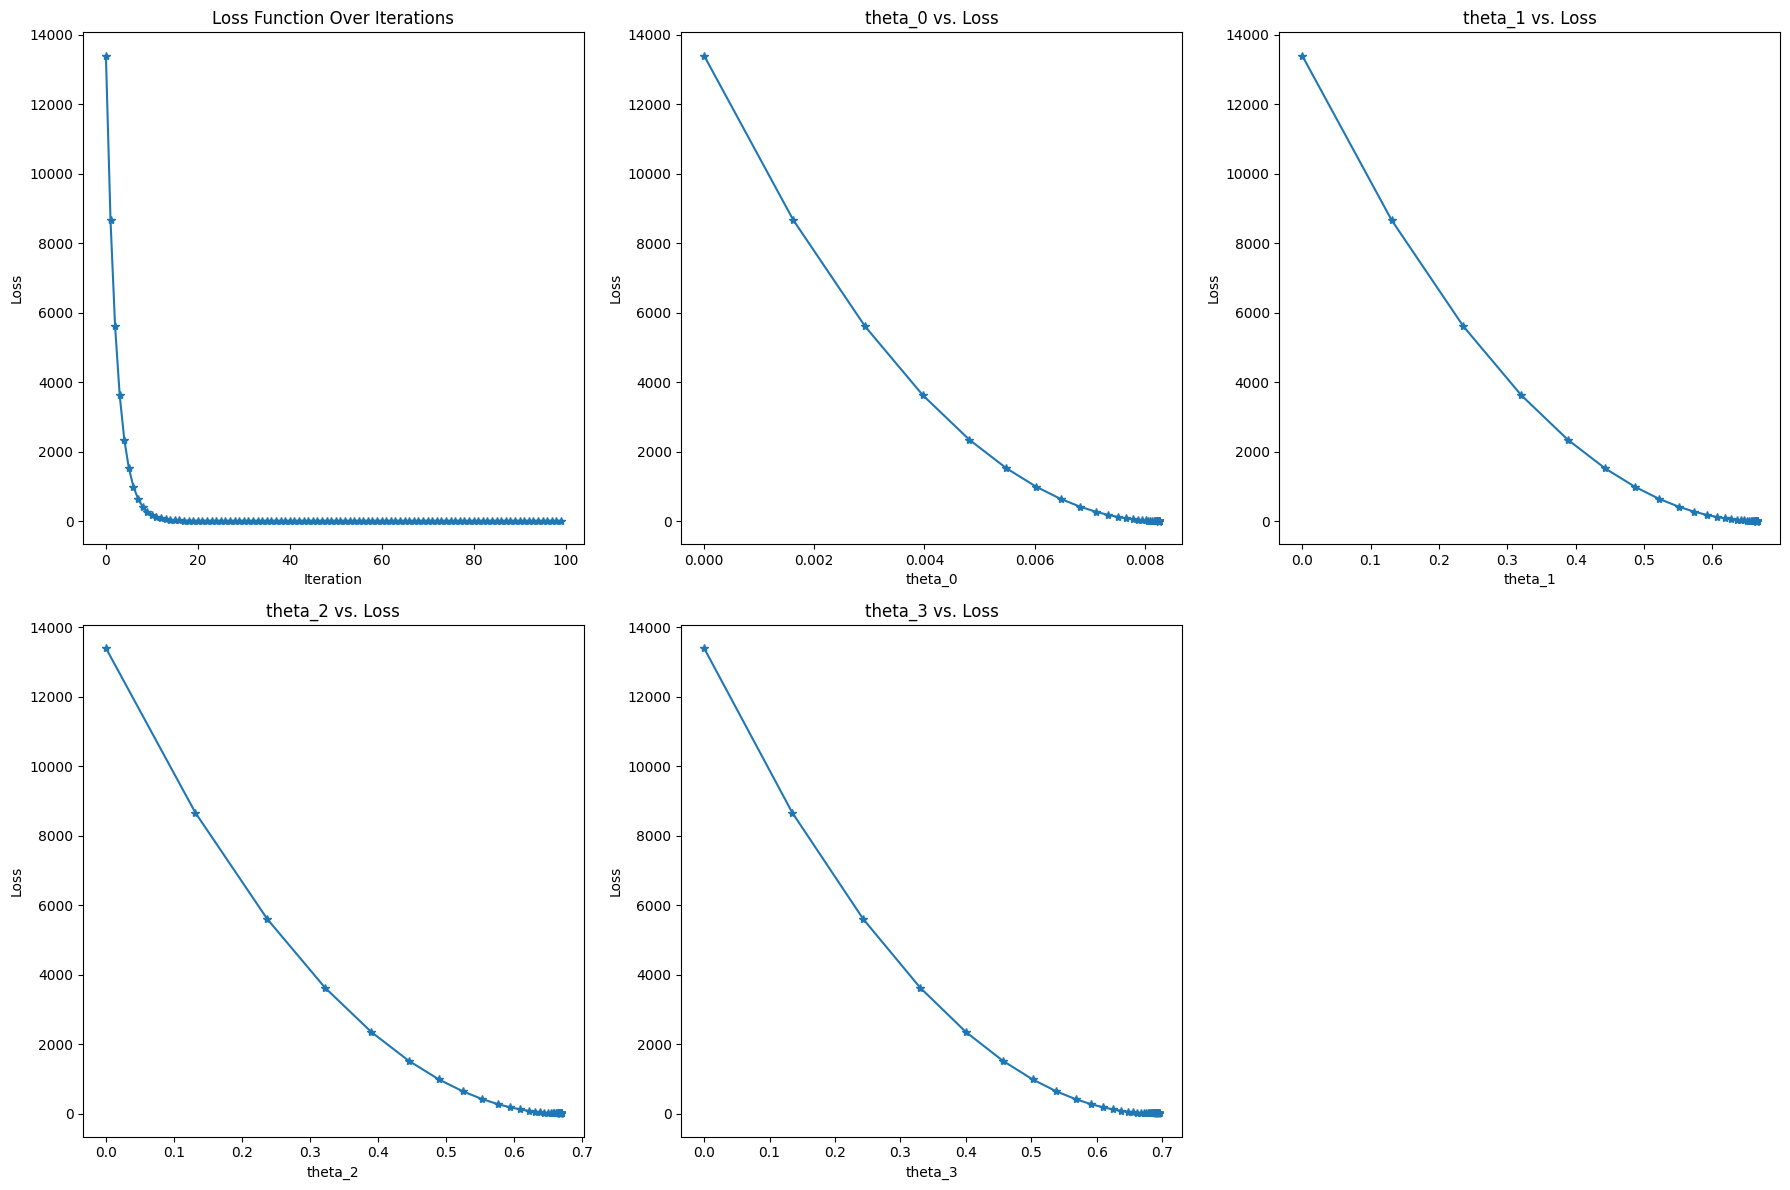

In [172]:
import numpy as np
import matplotlib.pyplot as plt

def plot_learning_curves(losses, thetas_values):
    num_thetas = len(thetas_values[0])
    num_plots_per_row = 3
    num_rows = (num_thetas + num_plots_per_row - 1) // num_plots_per_row
    plt.figure(figsize=(18, 6 * num_rows))
    plt.subplot(num_rows, num_plots_per_row, 1)
    plt.plot(losses, linestyle='-', marker='*')
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.title('Loss Function Over Iterations')
    theta_values = np.array(thetas_values)
    for i in range(num_thetas):
        plt.subplot(num_rows, num_plots_per_row, i + 2)
        plt.plot(theta_values[:, i], losses, linestyle='-', marker='*')
        plt.xlabel(f'theta_{i}')
        plt.ylabel('Loss')
        plt.title(f'theta_{i} vs. Loss')
    plt.tight_layout()
    plt.show()

plot_learning_curves(loss, thetas)


[153.89445931 185.00695088 182.26768895 198.52840291 141.08719914
 104.06117009 148.63149909 110.22158354 172.94206366 160.24538656
 143.18494752 141.21063713 188.28274579 156.48490342 149.32344235
 187.75873774 149.01328177 178.37889155 179.49052224 160.6014594
 174.29084664 173.58324723 166.16205527 155.10414814 191.72021344]


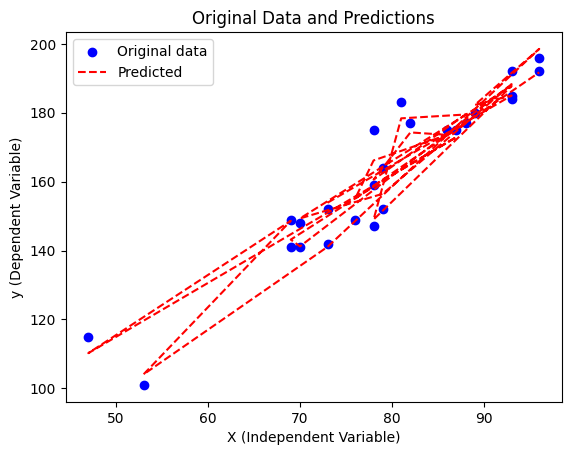

In [173]:
# Compare between y and y_predict for one model
def y_vs_ypredict(X, y, theta, state=1):
    y_predict = predict(X, theta)
    print(y_predict)
    plt.scatter(X[:, 1], y, color='blue', marker='o', label='Original data')  
    plt.plot(X[:, 1], y_predict, color='red', linestyle='--', label='Predicted')
    plt.xlabel('X (Independent Variable)')
    plt.ylabel('y (Dependent Variable)')
    plt.title('Original Data and Predictions')
    if state == 1:
        plt.legend()
        plt.show()

# Compare between models
def model_vs_model(X, y, thetas):
    for i in range(len(thetas)):
        y_vs_ypredict(X, y, thetas[i], state=2)


y_vs_ypredict(x, y, thetas[-1])


# Stochastic

In [174]:
def compute_gradients(X, y, y_predict):
    """Computes gradients for theta0 and theta1."""
    error = y_predict - y
    gradient_theta= X * error
    return gradient_theta
def update_parameters(theta, gradients, learning_rate):
    """Updates theta using the computed gradients."""
    new_theta = theta - learning_rate * np.array(gradients)
    return new_theta

Iteration 0: Cost = 452264.1583582033
Iteration 10: Cost = 950832.7016533476
Iteration 20: Cost = 2280731.9981816327
Iteration 30: Cost = 6112786.8749012975
Iteration 40: Cost = 17304555.7084017
Iteration 50: Cost = 50247357.557422295
Iteration 60: Cost = 147643771.53893185
Iteration 70: Cost = 436308274.3946419
Iteration 80: Cost = 1293010024.5331504
Iteration 90: Cost = 3837398338.447786
Iteration 100: Cost = 11397140736.207142
Iteration 110: Cost = 33862852654.1409
Iteration 120: Cost = 100632607604.39465
Iteration 130: Cost = 299087982029.49524
Iteration 140: Cost = 888959534279.2441
Iteration 150: Cost = 2642264277916.4756
Iteration 160: Cost = 7853727462039.83
Iteration 170: Cost = 23344132927637.742
Iteration 180: Cost = 69387394792189.02
Iteration 190: Cost = 206245114759076.44
Iteration 200: Cost = 613037070393141.5
Iteration 210: Cost = 1822173335196015.8
Iteration 220: Cost = 5416172718113485.0
Iteration 230: Cost = 1.6098863109591686e+16
Iteration 240: Cost = 4.785174925448

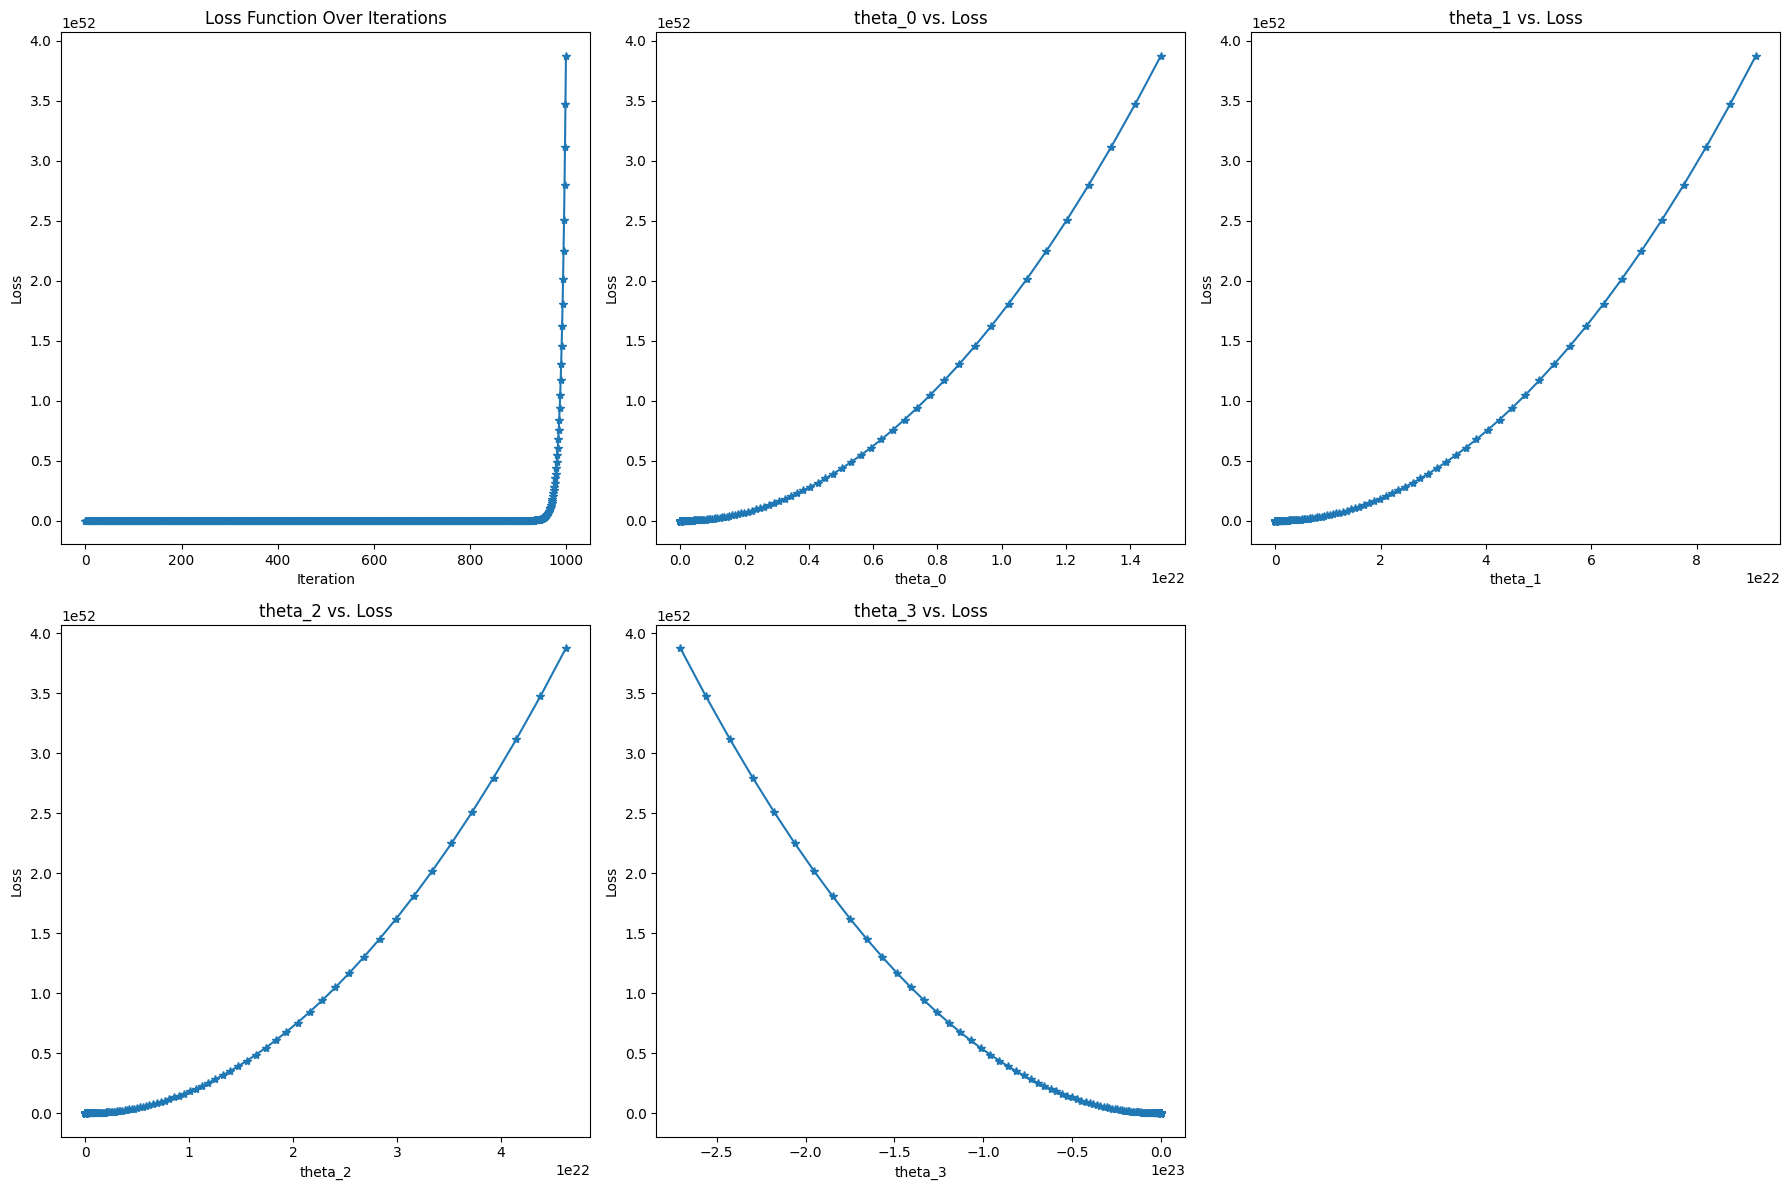

In [184]:
def Stochastic(X, y, maxi=100, alpha=0.01):
    """Performs gradient descent to learn theta."""
    m, n = X.shape
    theta = np.zeros(n)
    learning_rate = alpha
    arr_theta = []
    arr_losses = []
    for i in range(maxi):
        for ii in range(m):
            y_predict = predict(X[ii], theta)
            gradients = compute_gradients(X[ii], y[ii], y_predict)
            theta = update_parameters(theta, gradients, learning_rate)
        arr_theta.append(theta.copy())
        arr_losses.append(compute_mse_cost(y, predict(X, theta)))
        if i % 10 == 0:
            print(f"Iteration {i}: Cost = {compute_mse_cost(y, predict(X, theta))}")
    
    return  arr_theta, arr_losses


theta,  arr_losses = Stochastic(x, y, maxi=1000, alpha=0.0001)
print(f"Learned parameters: theta = {theta[-1]}")
plot_learning_curves (arr_losses,theta)


[153.89445931 185.00695088 182.26768895 198.52840291 141.08719914
 104.06117009 148.63149909 110.22158354 172.94206366 160.24538656
 143.18494752 141.21063713 188.28274579 156.48490342 149.32344235
 187.75873774 149.01328177 178.37889155 179.49052224 160.6014594
 174.29084664 173.58324723 166.16205527 155.10414814 191.72021344]


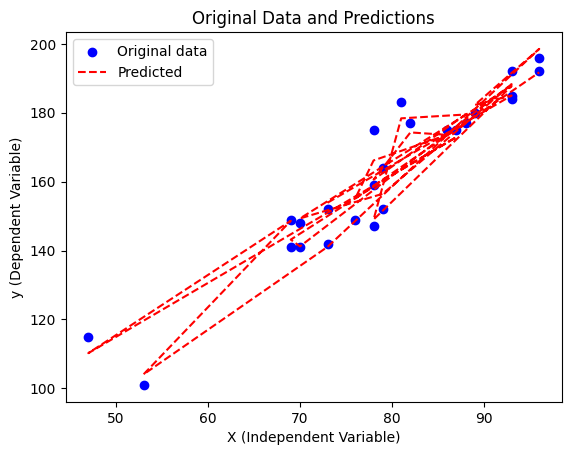

In [185]:
y_vs_ypredict(x, y, thetas[-1])

Iteration 0: Cost = 7317920.741721407
Iteration 10: Cost = 729348.5635404476
Iteration 20: Cost = 239743.661699825
Iteration 30: Cost = 191247.90870922207
Learned parameters: [0.00809613 0.64999431 0.63856696 0.78998038]


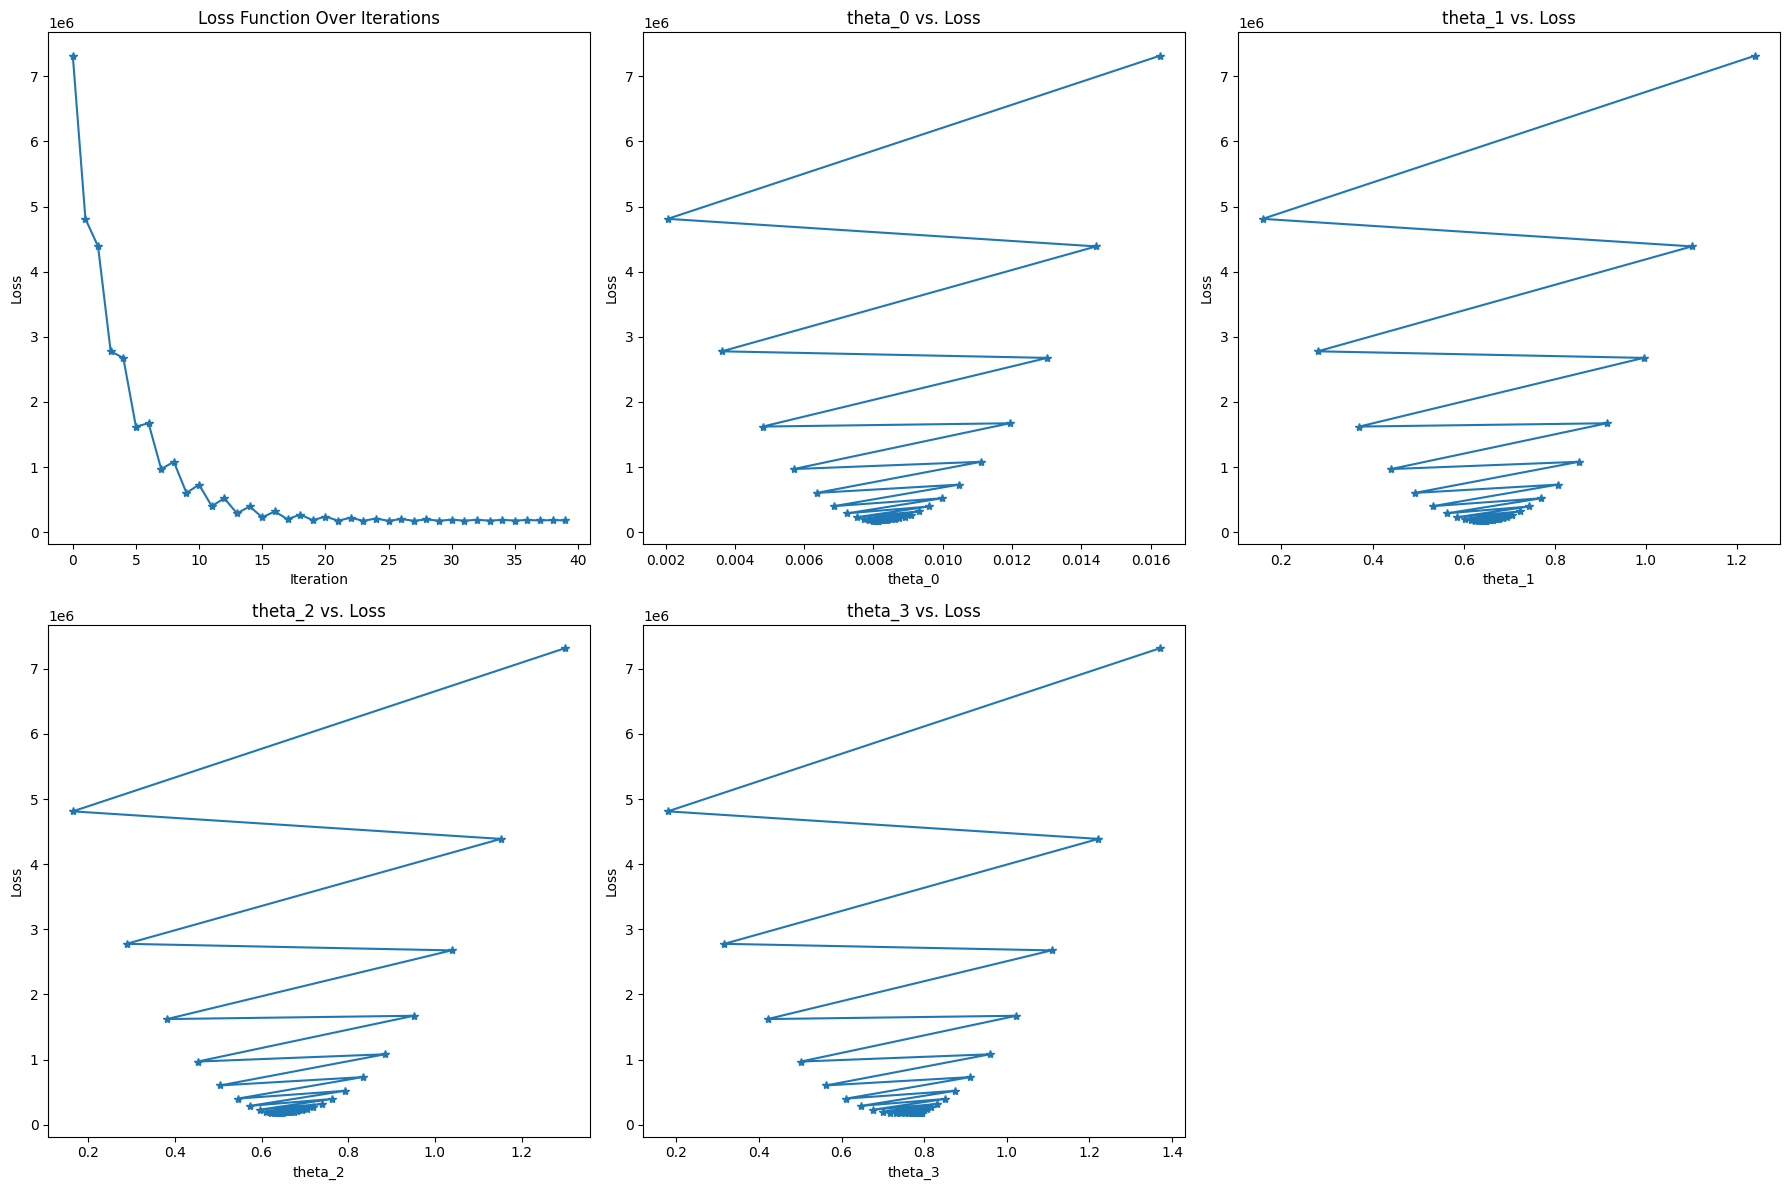

In [193]:
def mini(X, y, maxi=100, alpha=0.01, batch_size=10):
    """Performs batch gradient descent to learn theta."""
    m, n = X.shape
    theta = np.zeros(n)
    arr_theta = []
    arr_losses = []
    
    # Shuffle the data before batching
    data = np.hstack((X, y.reshape(-1, 1)))
    np.random.shuffle(data)
    X_shuffled = data[:, :-1]
    y_shuffled = data[:, -1]
    for i in range(maxi):
        for batch in range(0, m, batch_size):
            end = min(batch + batch_size, m)
            X_batch = X_shuffled[batch:end]
            y_batch = y_shuffled[batch:end]
            
            h = np.dot(X_batch, theta)
            e = h - y_batch
            grad = np.dot(X_batch.T, e) / (end - batch)
            theta -= alpha * grad
        
        arr_theta.append(theta.copy())
        arr_losses.append(compute_mse_cost(y, predict(X, theta)))
        
        if i % 10 == 0:
            print(f"Iteration {i}: Cost = {compute_mse_cost(y, predict(X, theta))}")
    
    return arr_theta, arr_losses
theta, arr_losses = mini(x, y, maxi=40, alpha=0.0001, batch_size=11)
print(f"Learned parameters: {theta[-1]}")
plot_learning_curves (arr_losses,theta)

[153.89445931 185.00695088 182.26768895 198.52840291 141.08719914
 104.06117009 148.63149909 110.22158354 172.94206366 160.24538656
 143.18494752 141.21063713 188.28274579 156.48490342 149.32344235
 187.75873774 149.01328177 178.37889155 179.49052224 160.6014594
 174.29084664 173.58324723 166.16205527 155.10414814 191.72021344]


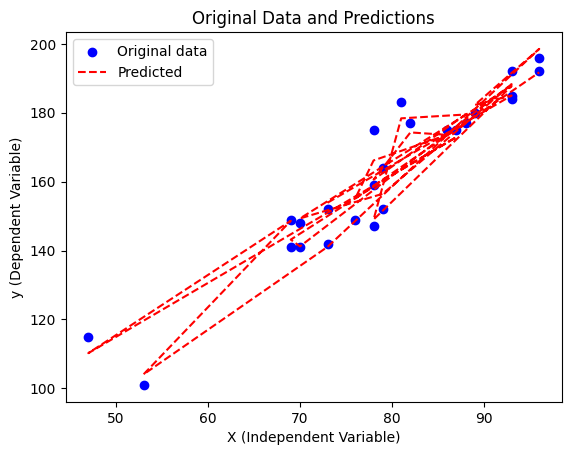

In [194]:
y_vs_ypredict(x, y, thetas[-1])